# Multinomial Logistic Regression

## Real-World Scenario: Classifying Tumor Subtypes from Gene Expression

A cancer diagnostics lab needs to classify **non-small cell lung cancer (NSCLC)** tumors into three subtypes based on gene expression biomarkers:

1. **Adenocarcinoma** (ADC) — the most common subtype
2. **Squamous Cell Carcinoma** (SCC) — linked to smoking history
3. **Large Cell Carcinoma** (LCC) — the rarest and most aggressive

Each tumor is profiled by two gene expression features: **TTF-1** (thyroid transcription factor 1, high in ADC) and **p63** (a squamous marker, high in SCC). This is a **multiclass classification** problem: given $\mathbf{x} = (x_1, x_2)$, predict $y \in \{1, 2, 3\}$.

We'll build a **multinomial logistic regression** model from Chapter 10.3, covering: the softmax function, multiclass cross-entropy loss, gradient derivation, SGD, nonlinear feature expansion, and MAP estimation with $\ell_2$ regularization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap
from itertools import combinations_with_replacement

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

## Key Formulas from PML Chapter 10.3

**Multinomial logistic regression model** (Eq. 10.54):

$$p(y \mid \mathbf{x}, \boldsymbol{\theta}) = \text{Cat}(y \mid \text{softmax}(W\mathbf{x} + \mathbf{b}))$$

where $W$ is a $C \times D$ weight matrix, $\mathbf{b}$ is a $C$-dimensional bias vector, and the **softmax** (Eq. 10.55):

$$p(y = c \mid \mathbf{x}, \boldsymbol{\theta}) = \frac{e^{a_c}}{\sum_{c'=1}^{C} e^{a_{c'}}}$$

where $\mathbf{a} = W\mathbf{x}$ is the vector of **logits**.

**Negative log-likelihood** (Eq. 10.58 — multiclass cross-entropy):

$$\text{NLL}(\boldsymbol{\theta}) = -\frac{1}{N} \sum_{n=1}^{N} \sum_{c=1}^{C} y_{nc} \log \mu_{nc} = \frac{1}{N} \sum_{n=1}^{N} H_{\text{ce}}(\mathbf{y}_n, \boldsymbol{\mu}_n)$$

where $\mu_{nc} = p(y_n = c \mid \mathbf{x}_n, \boldsymbol{\theta})$ and $y_{nc} = \mathbb{1}(y_n = c)$ is the one-hot encoding.

**Gradient** (Eq. 10.68):

$$\nabla_{\mathbf{w}_j} \text{NLL}_n = (\mu_{nj} - y_{nj})\mathbf{x}_n$$

In matrix form: $G(\mathbf{w}) = \frac{1}{N} \sum_n \mathbf{x}_n (\boldsymbol{\mu}_n - \mathbf{y}_n)^\top$

**Softmax Jacobian** (Eq. 10.60):

$$\frac{\partial \mu_c}{\partial a_j} = \mu_c(\delta_{cj} - \mu_j)$$

## 1. The Softmax Function

The softmax generalizes the sigmoid to $C$ classes. Given logits $\mathbf{a} = (a_1, \ldots, a_C)$ (Eq. 10.55):

$$\text{softmax}(\mathbf{a})_c = \frac{e^{a_c}}{\sum_{c'=1}^{C} e^{a_{c'}}}$$

For numerical stability, we use the **log-sum-exp** trick (Eq. 10.73):

$$p(y = c \mid \mathbf{x}) = \exp\left(a_c - \text{lse}(\mathbf{a})\right), \quad \text{lse}(\mathbf{a}) = \log \sum_{c'} e^{a_{c'}}$$

When $C = 2$, softmax reduces to the **sigmoid**: $\text{softmax}([a, 0])_1 = \sigma(a)$.

In [2]:
def softmax(a):
    """Numerically stable softmax using log-sum-exp trick.
    
    Args:
        a: logits, shape (N, C) or (C,)
    Returns:
        probabilities, same shape as a
    """
    a = np.atleast_2d(a)
    a_max = a.max(axis=1, keepdims=True)
    exp_a = np.exp(a - a_max)  # subtract max for stability
    return exp_a / exp_a.sum(axis=1, keepdims=True)


def log_softmax(a):
    """Numerically stable log-softmax: log p(y=c|x) = a_c - lse(a)."""
    a = np.atleast_2d(a)
    a_max = a.max(axis=1, keepdims=True)
    lse = a_max + np.log(np.exp(a - a_max).sum(axis=1, keepdims=True))
    return a - lse


# Verify softmax reduces to sigmoid for C=2
a_test = np.array([2.0, 0.0])  # logit for class 1, class 2 fixed at 0
softmax_result = softmax(a_test).ravel()
sigmoid_result = 1.0 / (1.0 + np.exp(-a_test[0]))

print("Softmax vs Sigmoid (C=2):")
print(f"  softmax([{a_test[0]}, 0]) = [{softmax_result[0]:.6f}, {softmax_result[1]:.6f}]")
print(f"  sigmoid({a_test[0]})       = {sigmoid_result:.6f}")
print(f"  Match: {np.allclose(softmax_result[0], sigmoid_result)}")

Softmax vs Sigmoid (C=2):
  softmax([2.0, 0]) = [0.880797, 0.119203]
  sigmoid(2.0)       = 0.880797
  Match: True


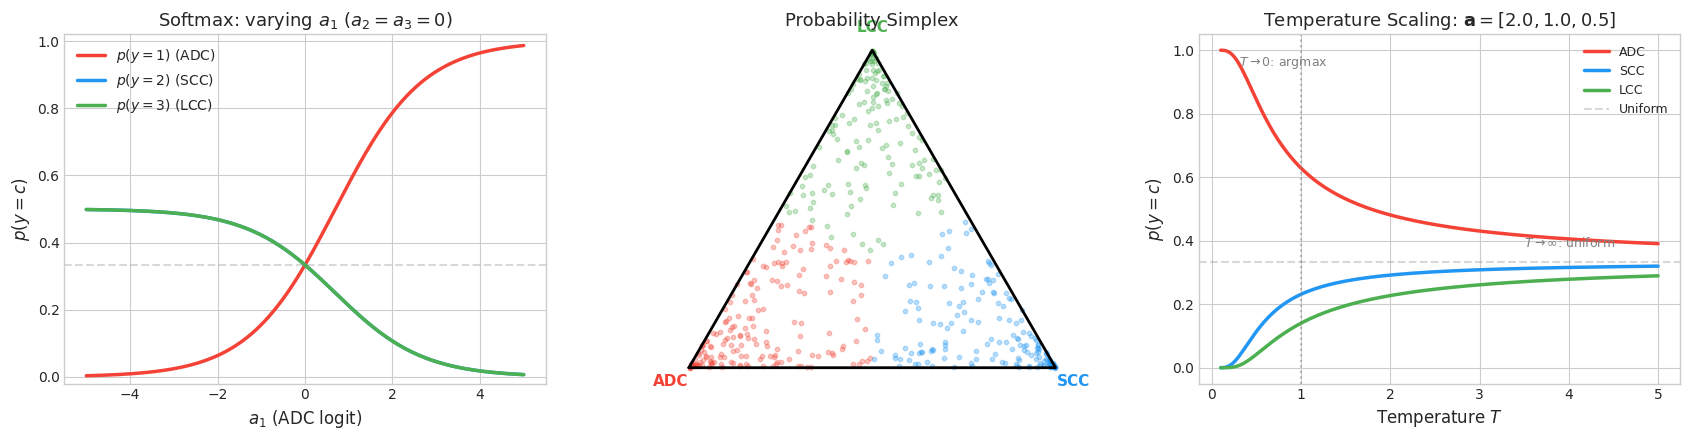

Left: as a₁ increases, class 1 (ADC) probability rises while others drop — all sum to 1.
Middle: softmax maps logits onto the probability simplex (triangle for C=3).
Right: temperature T→0 makes softmax peaked (hard); T→∞ makes it uniform (uncertain).


In [3]:
# Visualize softmax behavior
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# Left: softmax as function of a1, with a2=0, a3=0
a1_range = np.linspace(-5, 5, 200)
probs_sweep = np.array([softmax(np.array([a1, 0.0, 0.0])).ravel() for a1 in a1_range])

colors_3 = ['#F44336', '#2196F3', '#4CAF50']  # Red=ADC, Blue=SCC, Green=LCC
class_labels = ['ADC', 'SCC', 'LCC']

for c in range(3):
    axes[0].plot(a1_range, probs_sweep[:, c], color=colors_3[c], linewidth=2.5,
                label=f'$p(y={c+1})$ ({class_labels[c]})')
axes[0].axhline(1/3, color='gray', linestyle='--', alpha=0.3)
axes[0].set_xlabel('$a_1$ (ADC logit)', fontsize=12)
axes[0].set_ylabel('$p(y = c)$', fontsize=12)
axes[0].set_title('Softmax: varying $a_1$ ($a_2 = a_3 = 0$)', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].set_ylim(-0.02, 1.02)

# Middle: softmax on a simplex (ternary diagram)
# Show how different logit vectors map to probability simplex
np.random.seed(0)
n_points = 500
random_logits = np.random.randn(n_points, 3) * 2
random_probs = softmax(random_logits)

# Simplex coordinates: map (p1, p2, p3) to 2D
def simplex_to_2d(probs):
    """Map points on 3-class probability simplex to 2D coordinates."""
    x = probs[:, 1] + 0.5 * probs[:, 2]
    y = (np.sqrt(3) / 2) * probs[:, 2]
    return x, y

sx, sy = simplex_to_2d(random_probs)
# Color by which class has highest probability
dominant = random_probs.argmax(axis=1)
for c in range(3):
    mask = dominant == c
    axes[1].scatter(sx[mask], sy[mask], c=colors_3[c], alpha=0.3, s=10, label=class_labels[c])

# Draw simplex triangle
triangle = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])
axes[1].plot(triangle[:, 0], triangle[:, 1], 'k-', linewidth=2)
axes[1].text(-0.05, -0.05, 'ADC', fontsize=11, ha='center', fontweight='bold', color=colors_3[0])
axes[1].text(1.05, -0.05, 'SCC', fontsize=11, ha='center', fontweight='bold', color=colors_3[1])
axes[1].text(0.5, np.sqrt(3)/2 + 0.05, 'LCC', fontsize=11, ha='center', fontweight='bold', color=colors_3[2])
axes[1].set_aspect('equal')
axes[1].set_title('Probability Simplex', fontsize=13)
axes[1].axis('off')

# Right: temperature scaling
a_fixed = np.array([2.0, 1.0, 0.5])
temps = np.linspace(0.1, 5, 200)
probs_temp = np.array([softmax(a_fixed / T).ravel() for T in temps])

for c in range(3):
    axes[2].plot(temps, probs_temp[:, c], color=colors_3[c], linewidth=2.5, label=class_labels[c])
axes[2].axhline(1/3, color='gray', linestyle='--', alpha=0.3, label='Uniform')
axes[2].axvline(1.0, color='gray', linestyle=':', alpha=0.5)
axes[2].set_xlabel('Temperature $T$', fontsize=12)
axes[2].set_ylabel('$p(y = c)$', fontsize=12)
axes[2].set_title(f'Temperature Scaling: $\\mathbf{{a}} = {list(a_fixed)}$', fontsize=13)
axes[2].legend(fontsize=9)
axes[2].annotate('$T \\to 0$: argmax', xy=(0.3, 0.95), fontsize=9, color='gray')
axes[2].annotate('$T \\to \\infty$: uniform', xy=(3.5, 0.38), fontsize=9, color='gray')

plt.tight_layout()
plt.show()

print("Left: as a₁ increases, class 1 (ADC) probability rises while others drop — all sum to 1.")
print("Middle: softmax maps logits onto the probability simplex (triangle for C=3).")
print("Right: temperature T→0 makes softmax peaked (hard); T→∞ makes it uniform (uncertain).")

## 2. Softmax Jacobian (Eq. 10.60)

The Jacobian of softmax is crucial for deriving the gradient. For each pair of classes $c, j$ (Eq. 10.60):

$$\frac{\partial \mu_c}{\partial a_j} = \mu_c(\delta_{cj} - \mu_j)$$

In matrix form (Eq. 10.62): $\frac{\partial \boldsymbol{\mu}}{\partial \mathbf{a}} = \text{diag}(\boldsymbol{\mu}) - \boldsymbol{\mu}\boldsymbol{\mu}^\top$

For example, with 3 classes (Eq. 10.61):

$$\frac{\partial \mu_c}{\partial a_j} = \begin{pmatrix} \mu_1(1-\mu_1) & -\mu_1\mu_2 & -\mu_1\mu_3 \\ -\mu_2\mu_1 & \mu_2(1-\mu_2) & -\mu_2\mu_3 \\ -\mu_3\mu_1 & -\mu_3\mu_2 & \mu_3(1-\mu_3) \end{pmatrix}$$

Note how this generalizes the binary sigmoid derivative $\sigma'(a) = \sigma(a)(1 - \sigma(a))$ — the diagonal entries have the same form.

In [4]:
def softmax_jacobian(mu):
    """Compute the Jacobian of softmax: diag(mu) - mu mu^T (Eq. 10.62)."""
    return np.diag(mu) - np.outer(mu, mu)


# Example: compute Jacobian for a specific probability vector
a_example = np.array([2.0, 1.0, 0.5])
mu_example = softmax(a_example).ravel()

J_analytic = softmax_jacobian(mu_example)

# Verify numerically
eps = 1e-6
J_numerical = np.zeros((3, 3))
for j in range(3):
    a_plus = a_example.copy(); a_plus[j] += eps
    a_minus = a_example.copy(); a_minus[j] -= eps
    J_numerical[:, j] = (softmax(a_plus).ravel() - softmax(a_minus).ravel()) / (2 * eps)

print(f"Probabilities: mu = [{', '.join(f'{m:.4f}' for m in mu_example)}]")
print(f"\nAnalytic Jacobian (Eq. 10.61):")
print(np.array2string(J_analytic, precision=4, suppress_small=True))
print(f"\nNumerical Jacobian:")
print(np.array2string(J_numerical, precision=4, suppress_small=True))
print(f"\nMax error: {np.max(np.abs(J_analytic - J_numerical)):.2e}")
print(f"\nKey properties:")
print(f"  Row sums = {J_analytic.sum(axis=1)}  (each row sums to 0)")
print(f"  Symmetric: {np.allclose(J_analytic, J_analytic.T)}")

Probabilities: mu = [0.6285, 0.2312, 0.1402]

Analytic Jacobian (Eq. 10.61):
[[ 0.2335 -0.1453 -0.0881]
 [-0.1453  0.1778 -0.0324]
 [-0.0881 -0.0324  0.1206]]

Numerical Jacobian:
[[ 0.2335 -0.1453 -0.0881]
 [-0.1453  0.1778 -0.0324]
 [-0.0881 -0.0324  0.1206]]

Max error: 4.84e-11

Key properties:
  Row sums = [1.38777878e-17 2.08166817e-17 0.00000000e+00]  (each row sums to 0)
  Symmetric: True


## 3. Generate Synthetic Tumor Subtype Data

We simulate three NSCLC subtypes with two gene expression biomarkers. Each subtype has a characteristic biomarker profile.

In [5]:
# True weight matrix W (C x D) — each row is the weight vector for one class
# We use C=3 classes and D=3 features (bias + 2 gene expression)
C = 3
class_names = ['ADC', 'SCC', 'LCC']

# True parameters: W is C x D (including bias in first column)
W_true = np.array([
    [-0.5,  2.0, -0.5],   # ADC: high TTF-1, low p63
    [-0.5, -0.5,  2.0],   # SCC: low TTF-1, high p63
    [ 0.0, -0.5, -0.5],   # LCC: low both (baseline)
])

# Generate features
N = 300
X_raw = np.random.randn(N, 2) * 1.5  # TTF-1 and p63 expression
X = np.column_stack([np.ones(N), X_raw])  # prepend bias
D = X.shape[1]

# Generate labels from true multinomial logistic model
logits_true = X @ W_true.T  # (N, C)
probs_true = softmax(logits_true)  # (N, C)

# Sample y ~ Cat(probs_true)
y = np.array([np.random.choice(C, p=p) for p in probs_true])

# One-hot encode
Y_onehot = np.eye(C)[y]  # (N, C)

print(f"Generated {N} tumor samples with {C} subtypes:")
for c in range(C):
    print(f"  {class_names[c]} (y={c}): {(y == c).sum()} ({(y == c).mean():.0%})")
print(f"\nTrue weight matrix W ({C}x{D}):")
print(W_true)

Generated 300 tumor samples with 3 subtypes:
  ADC (y=0): 109 (36%)
  SCC (y=1): 102 (34%)
  LCC (y=2): 89 (30%)

True weight matrix W (3x3):
[[-0.5  2.  -0.5]
 [-0.5 -0.5  2. ]
 [ 0.  -0.5 -0.5]]


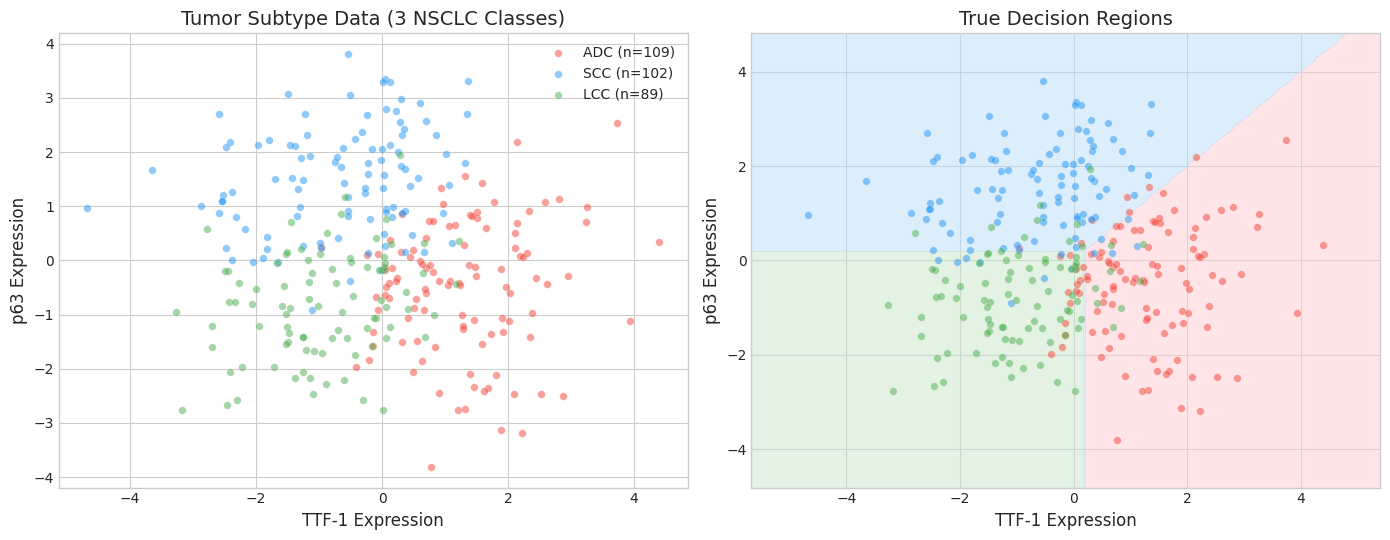

Each class occupies a wedge-shaped region — logistic regression creates LINEAR decision boundaries.
The boundaries meet at a single point where all classes are equally likely.


In [6]:
# Visualize the data
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: scatter by class
for c in range(C):
    mask = y == c
    axes[0].scatter(X_raw[mask, 0], X_raw[mask, 1], c=colors_3[c], alpha=0.5, s=30,
                    label=f'{class_names[c]} (n={mask.sum()})', edgecolors='white', linewidths=0.3)

axes[0].set_xlabel('TTF-1 Expression', fontsize=12)
axes[0].set_ylabel('p63 Expression', fontsize=12)
axes[0].set_title('Tumor Subtype Data (3 NSCLC Classes)', fontsize=14)
axes[0].legend(fontsize=10)

# Right: true decision regions
x1_grid = np.linspace(X_raw[:, 0].min() - 1, X_raw[:, 0].max() + 1, 200)
x2_grid = np.linspace(X_raw[:, 1].min() - 1, X_raw[:, 1].max() + 1, 200)
xx, yy = np.meshgrid(x1_grid, x2_grid)
grid_raw = np.column_stack([xx.ravel(), yy.ravel()])
grid_with_bias = np.column_stack([np.ones(len(grid_raw)), grid_raw])

probs_grid = softmax(grid_with_bias @ W_true.T)
pred_grid = probs_grid.argmax(axis=1).reshape(xx.shape)

cmap_3 = ListedColormap(['#FFCDD2', '#BBDEFB', '#C8E6C9'])
axes[1].contourf(xx, yy, pred_grid, levels=[-0.5, 0.5, 1.5, 2.5], cmap=cmap_3, alpha=0.5)

for c in range(C):
    mask = y == c
    axes[1].scatter(X_raw[mask, 0], X_raw[mask, 1], c=colors_3[c], alpha=0.5, s=30,
                    edgecolors='white', linewidths=0.3)

axes[1].set_xlabel('TTF-1 Expression', fontsize=12)
axes[1].set_ylabel('p63 Expression', fontsize=12)
axes[1].set_title('True Decision Regions', fontsize=14)

plt.tight_layout()
plt.show()

print("Each class occupies a wedge-shaped region — logistic regression creates LINEAR decision boundaries.")
print("The boundaries meet at a single point where all classes are equally likely.")

## 4. Multiclass Cross-Entropy Loss (Section 10.3.2)

### NLL = Cross-Entropy

The NLL is the average cross-entropy between one-hot labels and predicted probabilities (Eq. 10.58):

$$\text{NLL}(\boldsymbol{\theta}) = -\frac{1}{N} \sum_{n=1}^{N} \sum_{c=1}^{C} y_{nc} \log \mu_{nc} = \frac{1}{N} \sum_{n=1}^{N} H_{\text{ce}}(\mathbf{y}_n, \boldsymbol{\mu}_n)$$

where the cross-entropy is (Eq. 10.59):

$$H_{\text{ce}}(\mathbf{p}, \mathbf{q}) = -\sum_{c=1}^{C} p_c \log q_c$$

Since $\mathbf{y}_n$ is one-hot ($y_{nc} = 1$ only for the true class), this simplifies to $-\log \mu_{n, y_n}$: the negative log-probability of the correct class.

For numerical stability, we compute this using log-softmax (Eq. 10.73):

$$-\log p(y_n = c \mid \mathbf{x}_n) = -a_{nc} + \text{lse}(\mathbf{a}_n)$$

In [7]:
def cross_entropy_loss(W, X, Y_onehot):
    """Multiclass cross-entropy NLL (Eq. 10.58), computed via log-softmax for stability."""
    N = X.shape[0]
    logits = X @ W.T  # (N, C)
    log_probs = log_softmax(logits)  # numerically stable
    # NLL = -1/N * sum of log-prob of true class
    return -np.sum(Y_onehot * log_probs) / N


def cross_entropy_gradient(W, X, Y_onehot):
    """Gradient of cross-entropy NLL (Eq. 10.68).
    
    G(W) = (1/N) * sum_n x_n (mu_n - y_n)^T
    Returns gradient as a C x D matrix (same shape as W).
    """
    N = X.shape[0]
    logits = X @ W.T  # (N, C)
    mu = softmax(logits)  # (N, C)
    # G = (1/N) * (mu - Y)^T @ X, shape (C, D)
    return (mu - Y_onehot).T @ X / N


# Verify gradient numerically
W_test = np.random.randn(C, D) * 0.1
grad_analytic = cross_entropy_gradient(W_test, X, Y_onehot)

eps = 1e-5
grad_numerical = np.zeros_like(W_test)
for c in range(C):
    for d in range(D):
        W_plus = W_test.copy(); W_plus[c, d] += eps
        W_minus = W_test.copy(); W_minus[c, d] -= eps
        grad_numerical[c, d] = (cross_entropy_loss(W_plus, X, Y_onehot) -
                                cross_entropy_loss(W_minus, X, Y_onehot)) / (2 * eps)

print("Gradient verification:")
print(f"  Max error: {np.max(np.abs(grad_analytic - grad_numerical)):.2e}")
print(f"\nAnalytic gradient (C x D):")
print(np.array2string(grad_analytic, precision=4))
print(f"\nNumerical gradient:")
print(np.array2string(grad_numerical, precision=4))

Gradient verification:
  Max error: 1.01e-11

Analytic gradient (C x D):
[[-0.0184 -0.4244  0.2616]
 [-0.0258  0.2571 -0.5257]
 [ 0.0441  0.1673  0.2641]]

Numerical gradient:
[[-0.0184 -0.4244  0.2616]
 [-0.0258  0.2571 -0.5257]
 [ 0.0441  0.1673  0.2641]]


## 5. Gradient Derivation (Section 10.3.2.3)

The gradient has a beautifully simple form. For a single example $n$ and class $j$ (Eqs. 10.63–10.67):

$$\nabla_{\mathbf{w}_j} \text{NLL}_n = -\sum_c \frac{y_{nc}}{\mu_{nc}} \cdot \mu_{nc}(\delta_{jc} - \mu_{nj}) \cdot \mathbf{x}_n = (\mu_{nj} - y_{nj})\mathbf{x}_n$$

The key simplification: the softmax Jacobian $\mu_c(\delta_{jc} - \mu_j)$ (Eq. 10.60) cancels with the $1/\mu_c$ from the cross-entropy derivative, giving just $(\mu_{nj} - y_{nj})$.

This has the **same form** as binary logistic regression (Eq. 10.21): **error times input**.

Summing over all examples gives the full gradient as a $D \times C$ matrix (Eq. 10.68):

$$G(\mathbf{w}) = \frac{1}{N} \sum_{n=1}^{N} \mathbf{x}_n (\boldsymbol{\mu}_n - \mathbf{y}_n)^\top$$

In [8]:
# Step-by-step gradient derivation for a single example
n = 0  # pick the first example
x_n = X[n]  # (D,)
y_n = Y_onehot[n]  # (C,) one-hot

# Forward pass
a_n = W_test @ x_n  # logits (C,)
mu_n = softmax(a_n).ravel()  # probabilities (C,)

print(f"Example n={n}: true class = {y[n]} ({class_names[y[n]]})")
print(f"  x_n    = {x_n}")
print(f"  logits = {a_n}")
print(f"  mu_n   = [{', '.join(f'{m:.4f}' for m in mu_n)}]")
print(f"  y_n    = {y_n} (one-hot)")

# Step 1: dNLL/dmu = -y_nc / mu_nc for each class
dNLL_dmu = -y_n / np.clip(mu_n, 1e-12, None)
print(f"\nStep 1: dNLL/dmu = -y_nc/mu_nc = {dNLL_dmu}")

# Step 2: Softmax Jacobian dmu/da (Eq. 10.60)
J = softmax_jacobian(mu_n)
print(f"\nStep 2: Softmax Jacobian (Eq. 10.61):")
print(np.array2string(J, precision=4))

# Step 3: Chain rule: dNLL/da = J^T @ dNLL/dmu
dNLL_da = J.T @ dNLL_dmu
print(f"\nStep 3: dNLL/da = J^T @ dNLL/dmu = {dNLL_da}")
print(f"         mu_n - y_n               = {mu_n - y_n}")
print(f"         Match: {np.allclose(dNLL_da, mu_n - y_n)}  ← The beautiful simplification!")

# Step 4: dNLL/dW_j = (mu_nj - y_nj) * x_n (Eq. 10.67)
print(f"\nStep 4: Gradient for each class (error × input):")
for j in range(C):
    error_j = mu_n[j] - y_n[j]
    print(f"  dNLL/dw_{j} = ({mu_n[j]:.4f} - {y_n[j]:.0f}) × x_n = {error_j:.4f} × x_n")

Example n=0: true class = 2 (LCC)
  x_n    = [ 1.          0.01985965 -0.18291739]
  logits = [-0.05025897 -0.10458786 -0.06005164]
  mu_n   = [0.3404, 0.3224, 0.3371]
  y_n    = [0. 0. 1.] (one-hot)

Step 1: dNLL/dmu = -y_nc/mu_nc = [-0.         -0.         -2.96628172]

Step 2: Softmax Jacobian (Eq. 10.61):
[[ 0.2245 -0.1098 -0.1148]
 [-0.1098  0.2185 -0.1087]
 [-0.1148 -0.1087  0.2235]]

Step 3: dNLL/da = J^T @ dNLL/dmu = [ 0.34043994  0.32243766 -0.6628776 ]
         mu_n - y_n               = [ 0.34043994  0.32243766 -0.6628776 ]
         Match: True  ← The beautiful simplification!

Step 4: Gradient for each class (error × input):
  dNLL/dw_0 = (0.3404 - 0) × x_n = 0.3404 × x_n
  dNLL/dw_1 = (0.3224 - 0) × x_n = 0.3224 × x_n
  dNLL/dw_2 = (0.3371 - 1) × x_n = -0.6629 × x_n


## 6. Gradient Descent and SGD (Section 10.3.3)

With the gradient in hand, we can use standard optimization methods. The SGD update for class $j$:

$$\mathbf{w}_{j}^{(t+1)} = \mathbf{w}_j^{(t)} - \eta_t (\mu_{nj} - y_{nj}) \mathbf{x}_n$$

For numerical stability, many software libraries compute the cross-entropy loss directly from **unnormalized logits** $\mathbf{a} = W\mathbf{x}$ using (Eq. 10.73):

$$p(y = c \mid \mathbf{x}) = \exp(a_c - \text{lse}(\mathbf{a}))$$

In [9]:
def gradient_descent_multi(X, Y_onehot, lr=0.5, n_iters=200):
    """Full-batch gradient descent for multinomial logistic regression."""
    C = Y_onehot.shape[1]
    D = X.shape[1]
    W = np.zeros((C, D))
    history = {'W': [W.copy()], 'nll': [cross_entropy_loss(W, X, Y_onehot)]}
    
    for t in range(n_iters):
        grad = cross_entropy_gradient(W, X, Y_onehot)
        W = W - lr * grad
        history['W'].append(W.copy())
        history['nll'].append(cross_entropy_loss(W, X, Y_onehot))
    
    return W, history


def sgd_multi(X, Y_onehot, lr=0.1, n_epochs=50):
    """Stochastic gradient descent with single-sample updates."""
    N, D_ = X.shape
    C = Y_onehot.shape[1]
    W = np.zeros((C, D_))
    history = {'W': [W.copy()], 'nll': [cross_entropy_loss(W, X, Y_onehot)]}
    
    for epoch in range(n_epochs):
        for n in np.random.permutation(N):
            x_n = X[n]  # (D,)
            mu_n = softmax(W @ x_n).ravel()  # (C,)
            y_n = Y_onehot[n]  # (C,)
            # Update each class: w_j -= lr * (mu_nj - y_nj) * x_n
            W -= lr * np.outer(mu_n - y_n, x_n)
        history['W'].append(W.copy())
        history['nll'].append(cross_entropy_loss(W, X, Y_onehot))
    
    return W, history


# Run both optimizers
W_gd, hist_gd = gradient_descent_multi(X, Y_onehot, lr=1.0, n_iters=200)
W_sgd, hist_sgd = sgd_multi(X, Y_onehot, lr=0.01, n_epochs=100)

print("Gradient Descent Results")
print("=" * 55)
print(f"  NLL (GD):  {hist_gd['nll'][-1]:.6f}")
print(f"  NLL (SGD): {hist_sgd['nll'][-1]:.6f}")
print(f"\nTrue W:")
print(W_true)
print(f"\nLearned W (GD):")
print(np.array2string(W_gd, precision=3))

Gradient Descent Results
  NLL (GD):  0.404684
  NLL (SGD): 0.404712

True W:
[[-0.5  2.  -0.5]
 [-0.5 -0.5  2. ]
 [ 0.  -0.5 -0.5]]

Learned W (GD):
[[ 0.058  1.935 -0.964]
 [-0.464 -1.088  1.839]
 [ 0.406 -0.847 -0.874]]


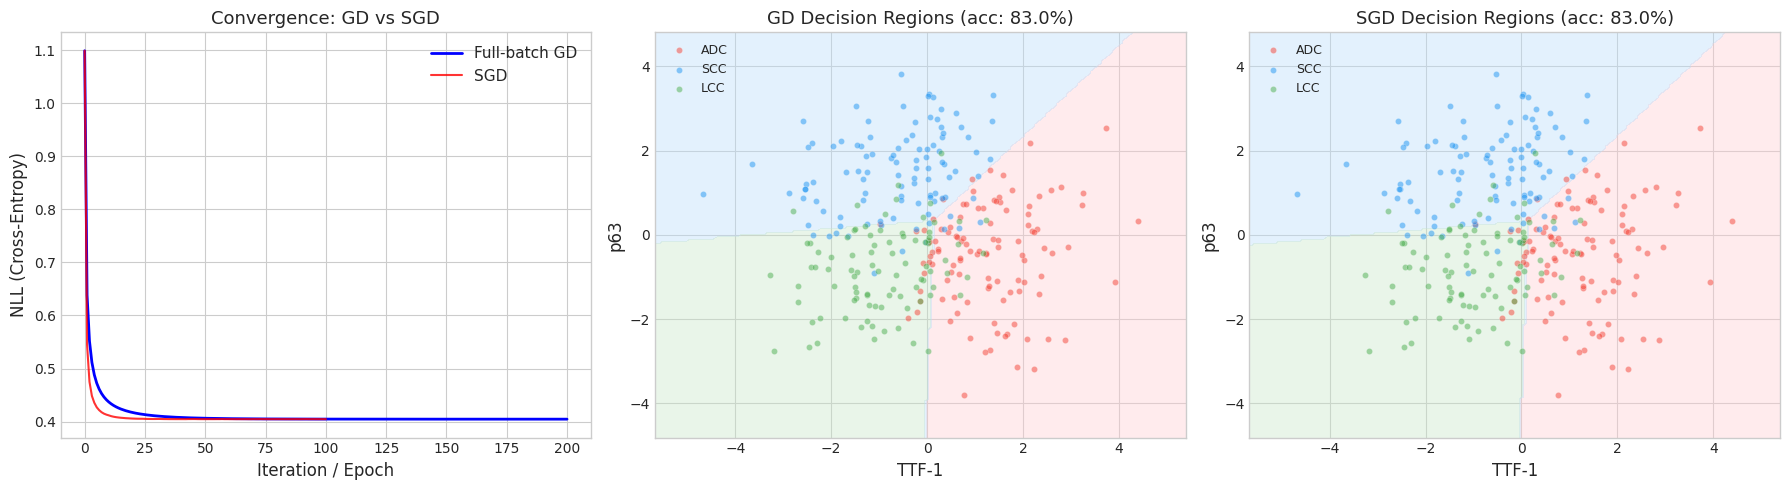

Both methods find similar linear decision boundaries that partition the feature space into 3 regions.


In [10]:
# Compare convergence and decision boundaries
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: convergence
axes[0].plot(hist_gd['nll'], 'b-', linewidth=2, label='Full-batch GD')
axes[0].plot(hist_sgd['nll'], 'r-', linewidth=1.5, alpha=0.8, label='SGD')
axes[0].set_xlabel('Iteration / Epoch', fontsize=12)
axes[0].set_ylabel('NLL (Cross-Entropy)', fontsize=12)
axes[0].set_title('Convergence: GD vs SGD', fontsize=13)
axes[0].legend(fontsize=11)

# Middle and Right: decision regions
for ax, (W_fit, title) in zip(axes[1:], [(W_gd, 'GD'), (W_sgd, 'SGD')]):
    probs_g = softmax(grid_with_bias @ W_fit.T)
    pred_g = probs_g.argmax(axis=1).reshape(xx.shape)
    
    ax.contourf(xx, yy, pred_g, levels=[-0.5, 0.5, 1.5, 2.5], cmap=cmap_3, alpha=0.4)
    for c in range(C):
        mask = y == c
        ax.scatter(X_raw[mask, 0], X_raw[mask, 1], c=colors_3[c], alpha=0.5, s=20,
                   edgecolors='white', linewidths=0.3, label=class_names[c])
    
    # Compute accuracy
    preds = softmax(X @ W_fit.T).argmax(axis=1)
    acc = (preds == y).mean()
    ax.set_xlabel('TTF-1', fontsize=12)
    ax.set_ylabel('p63', fontsize=12)
    ax.set_title(f'{title} Decision Regions (acc: {acc:.1%})', fontsize=13)
    ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

print("Both methods find similar linear decision boundaries that partition the feature space into 3 regions.")

## 7. Hessian and Convexity (Section 10.3.2.4)

The Hessian of the NLL for multinomial logistic regression is (Eq. 10.69):

$$H(\mathbf{w}) = \frac{1}{N} \sum_{n=1}^{N} \left(\text{diag}(\boldsymbol{\mu}_n) - \boldsymbol{\mu}_n \boldsymbol{\mu}_n^\top\right) \otimes (\mathbf{x}_n \mathbf{x}_n^\top)$$

where $\otimes$ is the Kronecker product. The block $(c, c')$ submatrix is (Eq. 10.70):

$$H_{c,c'}(\mathbf{w}) = \frac{1}{N} \sum_n \mu_{nc}(\delta_{c,c'} - \mu_{n,c'}) \mathbf{x}_n \mathbf{x}_n^\top$$

Since $\text{diag}(\boldsymbol{\mu}) - \boldsymbol{\mu}\boldsymbol{\mu}^\top \succcurlyeq 0$ (covariance of a categorical), and $\mathbf{x}_n\mathbf{x}_n^\top \succcurlyeq 0$, the Hessian is **positive semi-definite** — the NLL is **convex**.

In [11]:
def cross_entropy_hessian(W, X, Y_onehot):
    """Hessian of multiclass NLL (Eq. 10.69).
    
    Returns a (C*D) x (C*D) matrix, where w is the flattened weight vector.
    """
    N = X.shape[0]
    C_ = Y_onehot.shape[1]
    D_ = X.shape[1]
    
    logits = X @ W.T
    mu = softmax(logits)  # (N, C)
    
    H = np.zeros((C_ * D_, C_ * D_))
    
    for n in range(N):
        # Kronecker product: (diag(mu_n) - mu_n mu_n^T) ⊗ (x_n x_n^T)
        S_n = np.diag(mu[n]) - np.outer(mu[n], mu[n])  # (C, C)
        X_n = np.outer(X[n], X[n])  # (D, D)
        H += np.kron(S_n, X_n)
    
    return H / N


# Compute Hessian and verify PSD
H_full = cross_entropy_hessian(W_gd, X, Y_onehot)
eigenvalues = np.linalg.eigvalsh(H_full)

print(f"Hessian shape: {H_full.shape} (CD x CD = {C*D} x {C*D})")
print(f"Eigenvalue range: [{eigenvalues.min():.6f}, {eigenvalues.max():.6f}]")
print(f"All eigenvalues >= 0: {np.all(eigenvalues >= -1e-10)}")
print(f"Number of zero eigenvalues: {(np.abs(eigenvalues) < 1e-8).sum()}")
print(f"\nThe NLL is convex (PSD Hessian) — any local minimum is the global minimum.")
print(f"Zero eigenvalues reflect parameter redundancy: we can shift all logits by a constant")
print(f"without changing probabilities (since softmax is shift-invariant).")

Hessian shape: (9, 9) (CD x CD = 9 x 9)
Eigenvalue range: [-0.000000, 0.254434]
All eigenvalues >= 0: True
Number of zero eigenvalues: 3

The NLL is convex (PSD Hessian) — any local minimum is the global minimum.
Zero eigenvalues reflect parameter redundancy: we can shift all logits by a constant
without changing probabilities (since softmax is shift-invariant).


## 8. Linear and Nonlinear Classifiers (Section 10.3.1)

Multinomial logistic regression creates **linear decision boundaries** between classes (see Figure 10.7a). To capture nonlinear patterns, we can transform the inputs (Eq. 10.57):

$$\phi(\mathbf{x}) = [1, x_1, x_2, x_1^2, x_2^2, x_1 x_2]$$

The model is still linear in parameters — all convexity guarantees still hold — but the decision boundaries in the original input space can be **quadratic** or higher-order curves.

Let's create a dataset that is **not linearly separable** and show how polynomial features help.

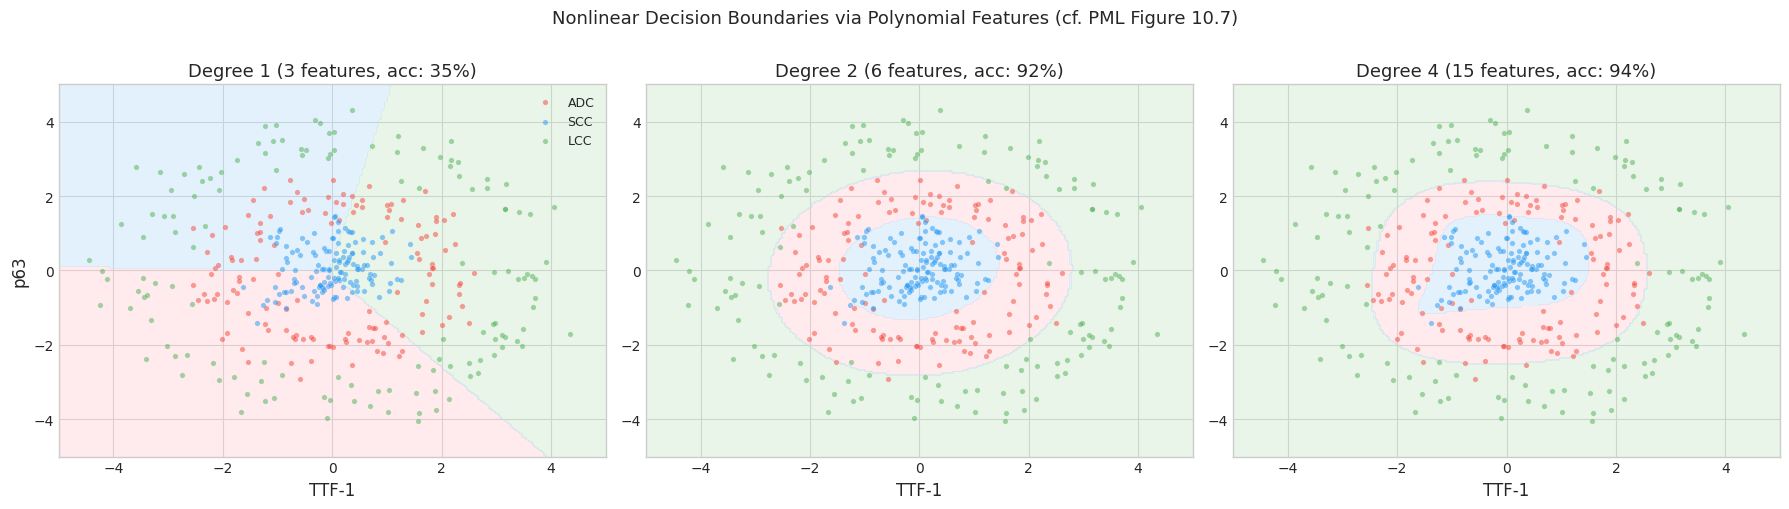

Degree 1 (linear): cannot capture concentric ring structure.
Degree 2: quadratic features (x₁², x₂², x₁x₂) capture the circular boundaries.
Degree 4: more flexible but same idea — still convex optimization.


In [12]:
def polynomial_features(X_raw, degree):
    """Create polynomial features up to given degree."""
    N, d = X_raw.shape
    features = [np.ones(N)]  # bias
    for deg in range(1, degree + 1):
        for combo in combinations_with_replacement(range(d), deg):
            feat = np.ones(N)
            for idx in combo:
                feat = feat * X_raw[:, idx]
            features.append(feat)
    return np.column_stack(features)


# Create a nonlinearly separable 3-class dataset
# Subtypes defined by different expression PATTERNS (not just levels)
np.random.seed(99)
N_nl = 400

# ADC: ring pattern (moderate expression of both markers)
n_per_class = N_nl // 3
theta_adc = np.random.uniform(0, 2 * np.pi, n_per_class)
r_adc = 2.0 + np.random.randn(n_per_class) * 0.4
X_adc = np.column_stack([r_adc * np.cos(theta_adc), r_adc * np.sin(theta_adc)])

# SCC: cluster at center
X_scc = np.random.randn(n_per_class, 2) * 0.6

# LCC: outer ring
n_lcc = N_nl - 2 * n_per_class
theta_lcc = np.random.uniform(0, 2 * np.pi, n_lcc)
r_lcc = 3.5 + np.random.randn(n_lcc) * 0.4
X_lcc = np.column_stack([r_lcc * np.cos(theta_lcc), r_lcc * np.sin(theta_lcc)])

X_nl = np.vstack([X_adc, X_scc, X_lcc])
y_nl = np.array([0]*n_per_class + [1]*n_per_class + [2]*n_lcc)
Y_nl_onehot = np.eye(C)[y_nl]

# Shuffle
perm = np.random.permutation(len(y_nl))
X_nl, y_nl, Y_nl_onehot = X_nl[perm], y_nl[perm], Y_nl_onehot[perm]

# Grid for plotting
x1_nl = np.linspace(-5, 5, 200)
x2_nl = np.linspace(-5, 5, 200)
xx_nl, yy_nl = np.meshgrid(x1_nl, x2_nl)
grid_nl = np.column_stack([xx_nl.ravel(), yy_nl.ravel()])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col, degree in enumerate([1, 2, 4]):
    X_poly = polynomial_features(X_nl, degree)
    X_poly_grid = polynomial_features(grid_nl, degree)
    
    W_nl, _ = gradient_descent_multi(X_poly, Y_nl_onehot, lr=0.5, n_iters=300)
    probs_nl_grid = softmax(X_poly_grid @ W_nl.T)
    pred_nl_grid = probs_nl_grid.argmax(axis=1).reshape(xx_nl.shape)
    
    ax = axes[col]
    ax.contourf(xx_nl, yy_nl, pred_nl_grid, levels=[-0.5, 0.5, 1.5, 2.5], cmap=cmap_3, alpha=0.4)
    
    for c in range(C):
        mask = y_nl == c
        ax.scatter(X_nl[mask, 0], X_nl[mask, 1], c=colors_3[c], alpha=0.5, s=15,
                   edgecolors='white', linewidths=0.2,
                   label=class_names[c] if col == 0 else '')
    
    preds_nl = softmax(X_poly @ W_nl.T).argmax(axis=1)
    acc_nl = (preds_nl == y_nl).mean()
    
    ax.set_xlabel('TTF-1', fontsize=12)
    if col == 0:
        ax.set_ylabel('p63', fontsize=12)
    ax.set_title(f'Degree {degree} ({X_poly.shape[1]} features, acc: {acc_nl:.0%})', fontsize=13)

axes[0].legend(fontsize=9)
plt.suptitle('Nonlinear Decision Boundaries via Polynomial Features (cf. PML Figure 10.7)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Degree 1 (linear): cannot capture concentric ring structure.")
print("Degree 2: quadratic features (x₁², x₂², x₁x₂) capture the circular boundaries.")
print("Degree 4: more flexible but same idea — still convex optimization.")

## 9. MAP Estimation and Identifiability (Section 10.3.5)

In multinomial logistic regression, the parameters are **unidentifiable** without regularization: we can add any vector $\mathbf{v}$ to all weight vectors $\mathbf{w}_c$ without changing probabilities (since softmax is shift-invariant).

**$\ell_2$ regularization** solves this (Eq. 10.86):

$$\text{PNLL}(W) = -\sum_{n=1}^{N} \log p(y_n \mid \mathbf{x}_n, W) + \lambda \sum_{c=1}^{C} \|\mathbf{w}_c\|_2^2$$

At the optimum, the weights satisfy a **sum-to-zero constraint** (Eq. 10.89):

$$\sum_{c=1}^{C} \hat{w}_{cj} = 0 \quad \text{for all feature dimensions } j$$

**Proof** (from the optimality condition, Eq. 10.87–10.89): at the optimum, $\nabla \text{NLL}(\mathbf{w}) + 2\lambda\mathbf{w} = 0$, so:

$$\lambda \sum_c w_{cj} = \sum_n \sum_c (y_{nc} - \mu_{nc}) x_{nj} = \sum_n \underbrace{\left(\sum_c y_{nc} - \sum_c \mu_{nc}\right)}_{= 1 - 1 = 0} x_{nj} = 0$$

Thus if $\lambda > 0$, we have $\sum_c \hat{w}_{cj} = 0$ — the weights are **uniquely identifiable**.

In [13]:
def gradient_descent_map(X, Y_onehot, lam=0.01, lr=0.5, n_iters=200):
    """Gradient descent with L2 regularization (MAP estimation, Eq. 10.86)."""
    C_ = Y_onehot.shape[1]
    D_ = X.shape[1]
    W = np.zeros((C_, D_))
    history = {'W': [W.copy()], 'loss': []}
    
    for t in range(n_iters):
        # Gradient of NLL + L2 penalty
        grad_nll = cross_entropy_gradient(W, X, Y_onehot)
        grad = grad_nll + 2 * lam * W
        W = W - lr * grad
        loss = cross_entropy_loss(W, X, Y_onehot) + lam * np.sum(W**2)
        history['W'].append(W.copy())
        history['loss'].append(loss)
    
    return W, history


# Compare MLE (no regularization) vs MAP (with L2) on the original linear data
W_mle, _ = gradient_descent_multi(X, Y_onehot, lr=1.0, n_iters=500)
W_map, _ = gradient_descent_map(X, Y_onehot, lam=0.1, lr=1.0, n_iters=500)

print("Identifiability: sum of weights across classes for each feature")
print("=" * 60)
print(f"{'Feature':>12s}  {'MLE sum':>12s}  {'MAP sum':>12s}")
print("-" * 60)
feature_names = ['bias', 'TTF-1', 'p63']
for d in range(D):
    mle_sum = W_mle[:, d].sum()
    map_sum = W_map[:, d].sum()
    print(f"{feature_names[d]:>12s}  {mle_sum:12.4f}  {map_sum:12.4f}")

print(f"\nWith L2 regularization, Σ_c w_cj ≈ 0 for each feature j.")
print(f"Without regularization, the sums can drift to arbitrary values.")

Identifiability: sum of weights across classes for each feature
     Feature       MLE sum       MAP sum
------------------------------------------------------------
        bias        0.0000        0.0000
       TTF-1        0.0000        0.0000
         p63        0.0000       -0.0000

With L2 regularization, Σ_c w_cj ≈ 0 for each feature j.
Without regularization, the sums can drift to arbitrary values.


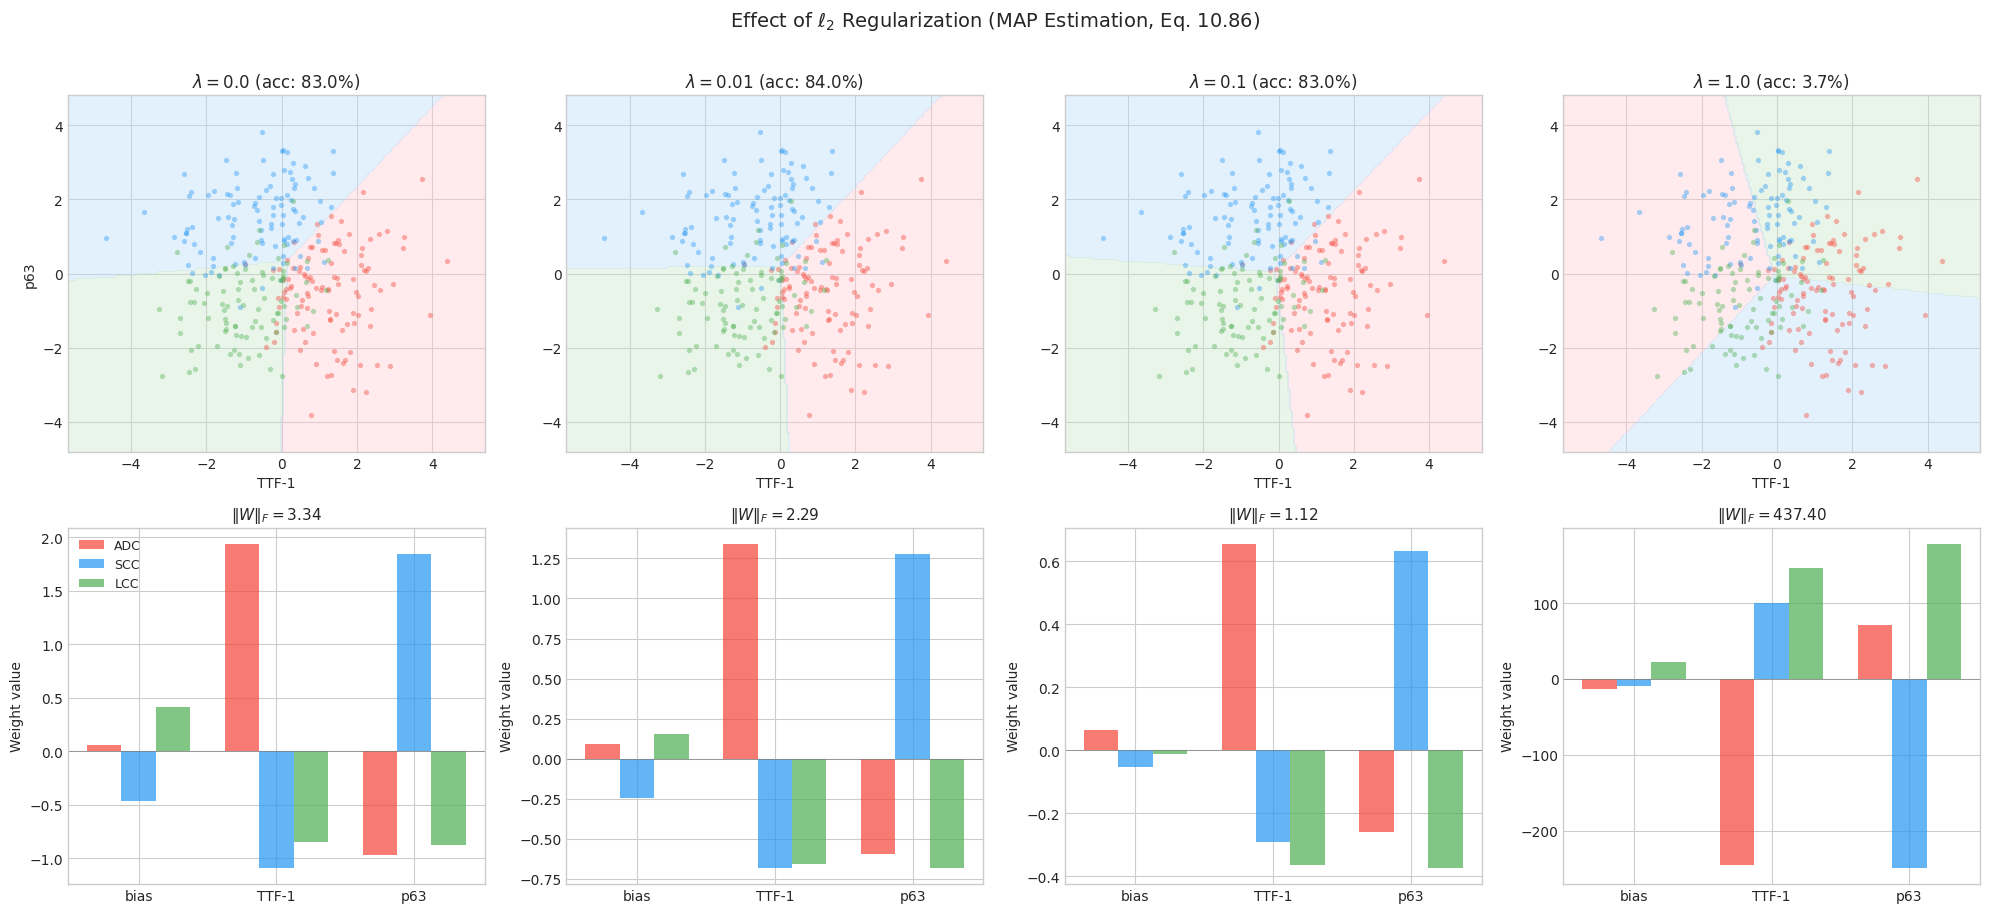

As λ increases: weights shrink, decision boundaries stay reasonable,
and the model becomes more 'uncertain' (probabilities closer to uniform).
Too much regularization (λ=1.0) underfits.


In [14]:
# Visualize regularization effect on decision boundaries and weight magnitudes
lambdas = [0.0, 0.01, 0.1, 1.0]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for col, lam in enumerate(lambdas):
    if lam == 0:
        W_fit, _ = gradient_descent_multi(X, Y_onehot, lr=1.0, n_iters=500)
    else:
        W_fit, _ = gradient_descent_map(X, Y_onehot, lam=lam, lr=1.0, n_iters=500)
    
    # Top: decision regions
    probs_g = softmax(grid_with_bias @ W_fit.T)
    pred_g = probs_g.argmax(axis=1).reshape(xx.shape)
    
    ax = axes[0, col]
    ax.contourf(xx, yy, pred_g, levels=[-0.5, 0.5, 1.5, 2.5], cmap=cmap_3, alpha=0.4)
    for c in range(C):
        mask = y == c
        ax.scatter(X_raw[mask, 0], X_raw[mask, 1], c=colors_3[c], alpha=0.4, s=15,
                   edgecolors='white', linewidths=0.2)
    
    preds = softmax(X @ W_fit.T).argmax(axis=1)
    acc = (preds == y).mean()
    ax.set_title(f'$\\lambda = {lam}$ (acc: {acc:.1%})', fontsize=12)
    ax.set_xlabel('TTF-1', fontsize=10)
    if col == 0:
        ax.set_ylabel('p63', fontsize=10)
    
    # Bottom: weight magnitudes (bar chart)
    ax2 = axes[1, col]
    bar_width = 0.25
    x_bar = np.arange(D)
    for c in range(C):
        ax2.bar(x_bar + c * bar_width, W_fit[c], bar_width,
                color=colors_3[c], alpha=0.7, label=class_names[c] if col == 0 else '')
    ax2.set_xticks(x_bar + bar_width)
    ax2.set_xticklabels(feature_names, fontsize=10)
    ax2.set_ylabel('Weight value', fontsize=10)
    ax2.set_title(f'$\\|W\\|_F = {np.linalg.norm(W_fit):.2f}$', fontsize=11)
    ax2.axhline(0, color='gray', linewidth=0.5)

axes[1, 0].legend(fontsize=9)
plt.suptitle('Effect of $\\ell_2$ Regularization (MAP Estimation, Eq. 10.86)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("As λ increases: weights shrink, decision boundaries stay reasonable,")
print("and the model becomes more 'uncertain' (probabilities closer to uniform).")
print("Too much regularization (λ=1.0) underfits.")

## 10. Maximum Entropy Interpretation (Section 10.3.6)

Multinomial logistic regression is also called a **maximum entropy classifier** (Eq. 10.90):

$$p(y = c \mid \mathbf{x}, W) = \frac{\exp(\mathbf{w}_c^\top \mathbf{x})}{Z(\mathbf{w}, \mathbf{x})}$$

where $Z(\mathbf{w}, \mathbf{x}) = \sum_c \exp(\mathbf{w}_c^\top \mathbf{x})$ is the **partition function**.

The more general **maxent classifier** (Eq. 10.91) uses class-dependent features:

$$p(y = c \mid \mathbf{x}, \mathbf{w}) = \frac{\exp(\mathbf{w}^\top \phi(\mathbf{x}, c))}{Z(\mathbf{w}, \mathbf{x})}$$

Multinomial logistic regression is a special case where $\phi(\mathbf{x}, c)$ embeds $\mathbf{x}$ in the $c$-th block (Eq. 10.92):

$$\phi(\mathbf{x}, c) = [\mathbf{0}, \ldots, \mathbf{x}, \ldots, \mathbf{0}]$$

The name "maximum entropy" comes from the fact that among all distributions matching the feature expectations $\mathbb{E}[\phi(\mathbf{x}, y)]$, the exponential family form maximizes entropy — it makes the fewest additional assumptions.

In [15]:
# Demonstrate the maxent feature embedding (Eq. 10.92)
# Show that phi(x, c) = [0, ..., x, ..., 0] with shared w gives same result as W @ x

def maxent_features(x, c, C_):
    """Maxent feature embedding: phi(x, c) = [0,...,x,...,0] (Eq. 10.92)."""
    D_ = len(x)
    phi = np.zeros(C_ * D_)
    phi[c * D_: (c + 1) * D_] = x
    return phi


# Example: show equivalence
x_demo = np.array([1.0, 0.5, -0.3])  # [bias, TTF-1, p63]
W_demo = W_gd  # learned weight matrix

# Standard formulation: logit_c = w_c^T x
logits_standard = W_demo @ x_demo

# Maxent formulation: logit_c = w^T phi(x, c), where w = vec(W)
w_flat = W_demo.flatten()  # flatten W into a single vector
logits_maxent = np.array([w_flat @ maxent_features(x_demo, c, C) for c in range(C)])

print("Equivalence of standard and maxent formulations:")
print(f"  Standard logits (W @ x):       {logits_standard}")
print(f"  Maxent logits (w^T phi(x,c)):  {logits_maxent}")
print(f"  Match: {np.allclose(logits_standard, logits_maxent)}")

print(f"\nFeature embeddings phi(x, c) for x = {x_demo}:")
for c in range(C):
    phi = maxent_features(x_demo, c, C)
    print(f"  phi(x, {c}) = {phi}  ({class_names[c]})")

print(f"\nThe maxent view is useful in NLP where features can depend on the class label.")

Equivalence of standard and maxent formulations:
  Standard logits (W @ x):       [ 1.314623   -1.55960759  0.24498459]
  Maxent logits (w^T phi(x,c)):  [ 1.314623   -1.55960759  0.24498459]
  Match: True

Feature embeddings phi(x, c) for x = [ 1.   0.5 -0.3]:
  phi(x, 0) = [ 1.   0.5 -0.3  0.   0.   0.   0.   0.   0. ]  (ADC)
  phi(x, 1) = [ 0.   0.   0.   1.   0.5 -0.3  0.   0.   0. ]  (SCC)
  phi(x, 2) = [ 0.   0.   0.   0.   0.   0.   1.   0.5 -0.3]  (LCC)

The maxent view is useful in NLP where features can depend on the class label.


## 11. Bound Optimization (Section 10.3.4)

Instead of computing the full Hessian (expensive for large $C$ and $D$), we can use a **fixed lower bound** on the Hessian (Eq. 10.79):

$$H(\mathbf{w}) \succ -\frac{1}{2} \left[I - \frac{\mathbf{1}\mathbf{1}^\top}{C}\right] \otimes \left(\sum_n \mathbf{x}_n \mathbf{x}_n^\top\right) \triangleq B$$

The bound optimization (MM algorithm) update is (Eq. 10.81):

$$\mathbf{w}_{t+1} = \mathbf{w}_t - B^{-1} \nabla \text{NLL}(\mathbf{w}_t)$$

The advantage: $B^{-1}$ can be **precomputed once**, since it doesn't depend on $\mathbf{w}$. This avoids the per-iteration Hessian inversion of Newton's method.

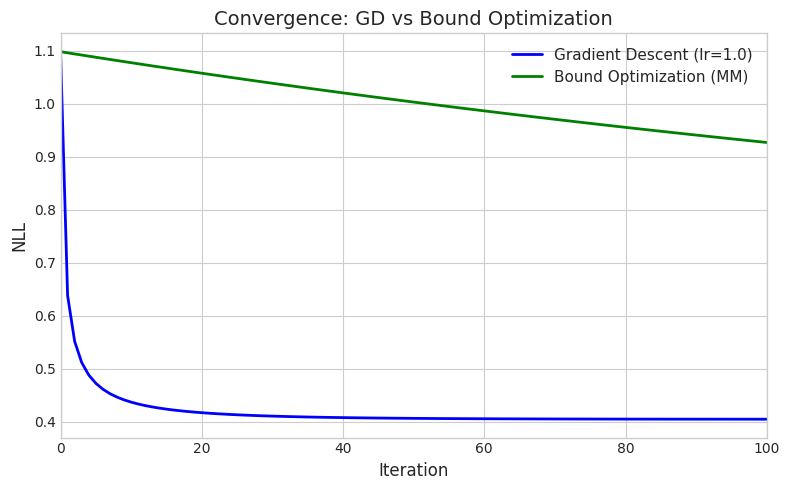

Final NLL — GD: 0.404805, Bound Opt: 0.927260

Bound optimization precomputes B⁻¹ once, avoiding per-iteration Hessian inversion.
It uses curvature information (like Newton) but with a fixed approximation.


In [16]:
def bound_optimization(X, Y_onehot, n_iters=100):
    """Bound optimization / MM algorithm for multinomial logistic regression (Eq. 10.79-10.81)."""
    N = X.shape[0]
    C_ = Y_onehot.shape[1]
    D_ = X.shape[1]
    
    # Precompute fixed Hessian bound B (Eq. 10.79)
    XtX = X.T @ X  # (D, D) — sum of x_n x_n^T
    I_C = np.eye(C_)
    ones_C = np.ones((C_, C_))
    B = 0.5 * np.kron(I_C - ones_C / C_, XtX)  # (CD, CD)
    
    # Precompute B^{-1} (only done once!)
    B_inv = np.linalg.pinv(B)  # use pseudo-inverse since B may be singular
    
    W = np.zeros((C_, D_))
    w = W.flatten()
    history = {'nll': [cross_entropy_loss(W, X, Y_onehot)]}
    
    for t in range(n_iters):
        W = w.reshape(C_, D_)
        grad = cross_entropy_gradient(W, X, Y_onehot).flatten()
        w = w - B_inv @ grad
        W = w.reshape(C_, D_)
        history['nll'].append(cross_entropy_loss(W, X, Y_onehot))
    
    return w.reshape(C_, D_), history


# Compare GD, Newton (full Hessian), and Bound Optimization
W_gd2, hist_gd2 = gradient_descent_multi(X, Y_onehot, lr=1.0, n_iters=100)
W_bo, hist_bo = bound_optimization(X, Y_onehot, n_iters=100)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(hist_gd2['nll'], 'b-', linewidth=2, label='Gradient Descent (lr=1.0)')
ax.plot(hist_bo['nll'], 'g-', linewidth=2, label='Bound Optimization (MM)')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('NLL', fontsize=12)
ax.set_title('Convergence: GD vs Bound Optimization', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

print(f"Final NLL — GD: {hist_gd2['nll'][-1]:.6f}, Bound Opt: {hist_bo['nll'][-1]:.6f}")
print(f"\nBound optimization precomputes B⁻¹ once, avoiding per-iteration Hessian inversion.")
print(f"It uses curvature information (like Newton) but with a fixed approximation.")

## 12. Putting It All Together: Full Evaluation

Let's return to the original linear dataset and compare all methods side by side, including per-class probability calibration.

In [17]:
# Train/test split
N_train = 220
X_train, X_test = X[:N_train], X[N_train:]
y_train, y_test = y[:N_train], y[N_train:]
Y_train, Y_test = Y_onehot[:N_train], Y_onehot[N_train:]
X_train_raw, X_test_raw = X_raw[:N_train], X_raw[N_train:]

# Fit all methods
W_gd_f, _ = gradient_descent_multi(X_train, Y_train, lr=1.0, n_iters=300)
W_sgd_f, _ = sgd_multi(X_train, Y_train, lr=0.01, n_epochs=100)
W_map_f, _ = gradient_descent_map(X_train, Y_train, lam=0.05, lr=1.0, n_iters=300)
W_bo_f, _ = bound_optimization(X_train, Y_train, n_iters=100)

print("="* 75)
print(f"{'Method':25s} {'Train Acc':>10s} {'Test Acc':>10s} {'Test NLL':>10s} {'||W||_F':>10s}")
print("-" * 75)

for name, W_fit in [('Gradient Descent', W_gd_f), ('SGD', W_sgd_f),
                     ('MAP (λ=0.05)', W_map_f), ('Bound Optimization', W_bo_f)]:
    pred_train = softmax(X_train @ W_fit.T).argmax(axis=1)
    pred_test = softmax(X_test @ W_fit.T).argmax(axis=1)
    acc_train = (pred_train == y_train).mean()
    acc_test = (pred_test == y_test).mean()
    nll_test = cross_entropy_loss(W_fit, X_test, Y_test)
    norm_W = np.linalg.norm(W_fit)
    print(f"{name:25s} {acc_train:9.1%} {acc_test:9.1%} {nll_test:10.4f} {norm_W:10.2f}")

print("=" * 75)

Method                     Train Acc   Test Acc   Test NLL    ||W||_F
---------------------------------------------------------------------------
Gradient Descent              82.7%     85.0%     0.3792       3.35
SGD                           82.7%     85.0%     0.3787       3.35
MAP (λ=0.05)                  82.3%     86.2%     0.4714       1.44
Bound Optimization            81.4%     85.0%     0.8737       0.30


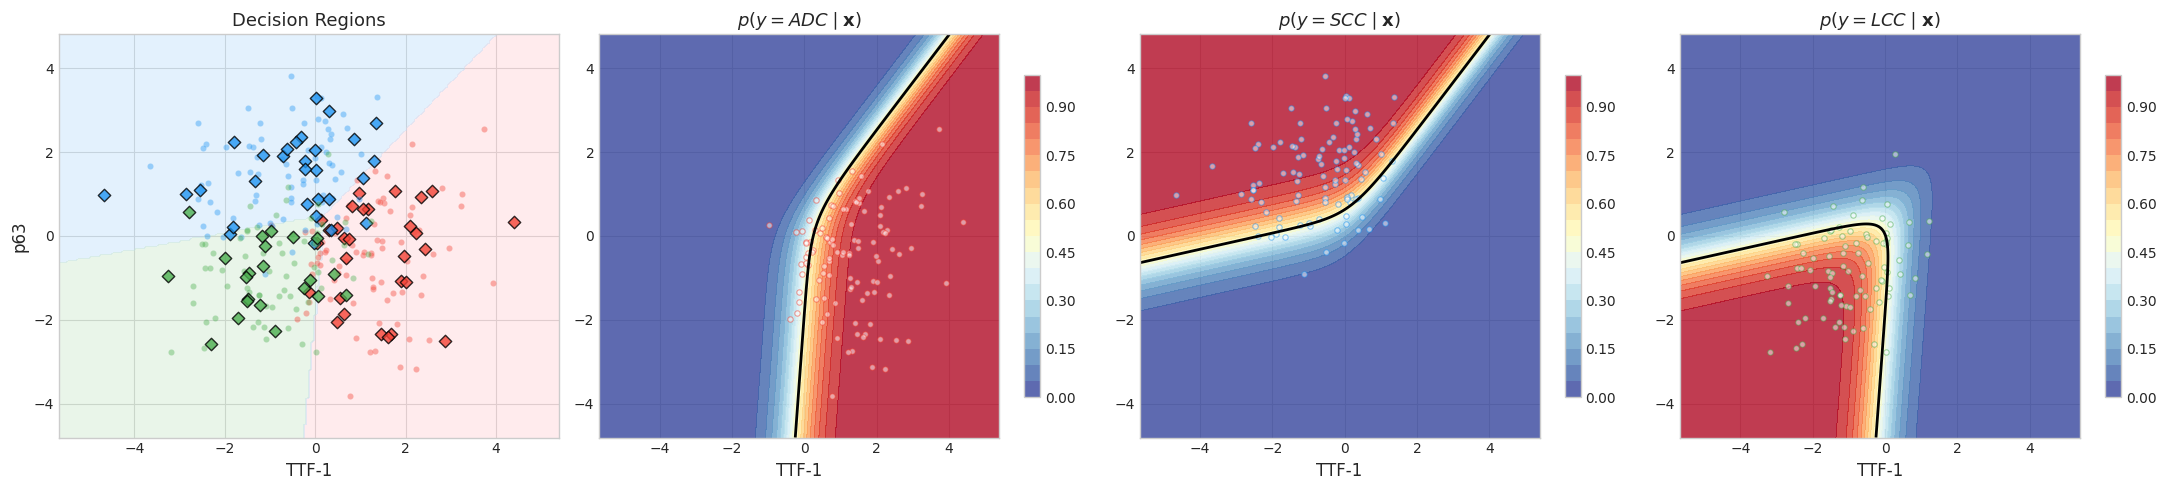

Each class probability surface shows a smooth gradient from 0 to 1.
The three probabilities sum to 1 everywhere (softmax normalization).


In [18]:
# Visualize: final decision regions + per-class probability heatmaps
W_final = W_gd_f  # use GD solution for visualization

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# First panel: decision regions
probs_final = softmax(grid_with_bias @ W_final.T)
pred_final = probs_final.argmax(axis=1).reshape(xx.shape)

axes[0].contourf(xx, yy, pred_final, levels=[-0.5, 0.5, 1.5, 2.5], cmap=cmap_3, alpha=0.4)
for c in range(C):
    mask_tr = y_train == c
    mask_te = y_test == c
    axes[0].scatter(X_train_raw[mask_tr, 0], X_train_raw[mask_tr, 1], c=colors_3[c],
                    alpha=0.4, s=20, edgecolors='white', linewidths=0.2)
    axes[0].scatter(X_test_raw[mask_te, 0], X_test_raw[mask_te, 1], c=colors_3[c],
                    alpha=0.8, s=40, edgecolors='black', linewidths=1, marker='D')

axes[0].set_xlabel('TTF-1', fontsize=12)
axes[0].set_ylabel('p63', fontsize=12)
axes[0].set_title('Decision Regions', fontsize=13)

# Panels 2-4: per-class probability heatmaps
for c in range(C):
    ax = axes[c + 1]
    prob_c = probs_final[:, c].reshape(xx.shape)
    im = ax.contourf(xx, yy, prob_c, levels=20, cmap='RdYlBu_r', vmin=0, vmax=1, alpha=0.8)
    ax.contour(xx, yy, prob_c, levels=[0.5], colors='black', linewidths=2)
    
    mask = y == c
    ax.scatter(X_raw[mask, 0], X_raw[mask, 1], c='white', alpha=0.5, s=15,
               edgecolors=colors_3[c], linewidths=0.8)
    
    ax.set_xlabel('TTF-1', fontsize=12)
    ax.set_title(f'$p(y = {class_names[c]} \\mid \\mathbf{{x}})$', fontsize=13)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

print("Each class probability surface shows a smooth gradient from 0 to 1.")
print("The three probabilities sum to 1 everywhere (softmax normalization).")

## Summary

### Key Takeaways

- **Multinomial logistic regression** models $p(y=c \mid \mathbf{x}) = \text{softmax}(W\mathbf{x})_c$ — a natural extension of binary logistic regression to $C$ classes
- The **softmax** maps logits to the probability simplex; numerically, use the **log-sum-exp** trick
- The **NLL** is multiclass cross-entropy: $-\frac{1}{N}\sum_n \sum_c y_{nc} \log \mu_{nc}$
- The **gradient** has the same elegant form as the binary case: $(\mu_{nj} - y_{nj})\mathbf{x}_n$ — error times input
- The **Hessian** involves Kronecker products of softmax covariance and outer products; it is **PSD**, so the NLL is **convex**
- **Polynomial features** create nonlinear decision boundaries while preserving convexity
- **$\ell_2$ regularization** (MAP) makes parameters **identifiable** by enforcing $\sum_c \hat{w}_{cj} = 0$
- **Bound optimization** precomputes a fixed Hessian approximation, avoiding per-iteration inversions
- The model is equivalent to a **maximum entropy classifier** with block-structured features

### Key Formulas from Chapter 10.3

| Concept | Formula |
|---------|--------|
| Model | $p(y=c \mid \mathbf{x}) = \frac{\exp(\mathbf{w}_c^\top \mathbf{x})}{\sum_{c'} \exp(\mathbf{w}_{c'}^\top \mathbf{x})}$ |
| NLL (cross-entropy) | $-\frac{1}{N}\sum_n \sum_c y_{nc} \log \mu_{nc}$ |
| Softmax Jacobian | $\frac{\partial \mu_c}{\partial a_j} = \mu_c(\delta_{cj} - \mu_j)$ |
| Gradient | $\nabla_{\mathbf{w}_j}\text{NLL}_n = (\mu_{nj} - y_{nj})\mathbf{x}_n$ |
| Hessian | $\frac{1}{N}\sum_n (\text{diag}(\boldsymbol{\mu}_n) - \boldsymbol{\mu}_n\boldsymbol{\mu}_n^\top) \otimes (\mathbf{x}_n\mathbf{x}_n^\top) \succcurlyeq 0$ |
| MAP objective | $\text{NLL}(W) + \lambda \sum_c \|\mathbf{w}_c\|_2^2$ |
| Sum-to-zero | $\sum_c \hat{w}_{cj} = 0$ for all $j$ (when $\lambda > 0$) |